# Recommendation System

## Data Description:

## Unique ID of each anime.
- Anime title.
- Anime broadcast type, such as TV, OVA, etc.
### Anime genre.
- The number of episodes of each anime.
- The average rating for each anime compared to the number of users who gave ratings.
- Number of community members for each anime.
## Objective:
- The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix
from scipy.sparse import hstack
from sklearn.metrics.pairwise import cosine_similarity

## Data Preprocessing:
1. Load the dataset into a suitable data structure (e.g., pandas DataFrame).
2. Handle missing values, if any.
3. Explore the dataset to understand its structure and attributes.

In [2]:
df = pd.read_csv("anime.csv")
df.head(7)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148,9.13,425855


In [3]:
df.shape

(12294, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [6]:
print("Duplicates: ", df.duplicated().sum())

Duplicates:  0


In [7]:
df["name"] = df["name"].astype(str).apply(html.unescape)

In [8]:
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].median())

In [9]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [10]:
df["episodes_num"] = pd.to_numeric(
    df["episodes"].replace("Unknown", np.nan),
    errors="coerce"
)

In [11]:
df["episodes_num"].isnull().sum()

340

In [12]:
df["episodes_num"] = df["episodes_num"].fillna(
    df["episodes_num"].median()
)

In [13]:
df["members_log"] = np.log1p(df["members"])

## Feature Extraction:

1. Decide on the features that will be used for computing similarity (e.g., genres, user ratings).
2. Convert categorical features into numerical representations if necessary.
3. Normalize numerical features if required.

In [14]:
tfidf = TfidfVectorizer(
    token_pattern=r"[^,]+",
    lowercase=True
)
genre_matrix = tfidf.fit_transform(df["genre"])
print("Genre Matrix Shape:", genre_matrix.shape)

Genre Matrix Shape: (12294, 83)


In [15]:
encoder = OneHotEncoder(handle_unknown="ignore")
type_matrix = encoder.fit_transform(
    df[["type"]]
)
print("Type Matrix Shape:", type_matrix.shape)

Type Matrix Shape: (12294, 7)


In [16]:
scaler = StandardScaler()
num_features = scaler.fit_transform(
    df[[
        "episodes_num",
        "rating",
        "members_log"
    ]]
)
num_matrix = csr_matrix(num_features)

In [17]:
X = hstack([
    genre_matrix,
    type_matrix,
    num_matrix
]).tocsr()
print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (12294, 93)


## Recommendation System:

1. Design a function to recommend anime based on cosine similarity.
2. Given a target anime, recommend a list of similar anime based on cosine similarity scores.
3. Experiment with different threshold values for similarity scores to adjust the recommendation list size.
4. Analyze the performance of the recommendation system and identify areas of improvement.

In [18]:
def recommend_anime(title, n=10, threshold=0.25):
    matches = df.index[
        df["name"].str.casefold() == title.casefold()
    ].tolist()
    if not matches:
        partial = df[
            df["name"].str.contains(
                title,
                case=False,
                na=False
            )
        ]
        if partial.empty:
            print(f"Anime '{title}' not found.")
            return
        idx = partial.index[0]
    else:
        idx = matches[0]
    similarity_scores = cosine_similarity(
        X[idx],
        X
    ).ravel()
    similarity_scores[idx] = -1
    recommendations = df.loc[
        similarity_scores >= threshold,
        [
            "name",
            "genre",
            "type",
            "rating",
            "members"
        ]
    ].copy()
    recommendations["similarity"] = (
        similarity_scores[recommendations.index]
    )
    recommendations = recommendations.sort_values(
        by="similarity",
        ascending=False
    )
    return recommendations.head(n).reset_index(drop=True)

In [19]:
recommend_anime(
    "Death Note",
    n=10,
    threshold=0.25
)

,name,genre,type,rating,members,similarity
0,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,8.41,218101,0.984905
1,Re:Zero kara Hajimeru Isekai Seikatsu,"Drama, Fantasy, Psychological, Thriller",TV,8.64,355839,0.963285
2,Boku dake ga Inai Machi,"Mystery, Psychological, Seinen, Supernatural",TV,8.65,402381,0.962911
3,Psycho-Pass,"Action, Police, Psychological, Sci-Fi",TV,8.50,509109,0.962206
4,Shiki,"Mystery, Supernatural, Thriller, Vampire",TV,7.99,251093,0.960233
5,Ergo Proxy,"Mystery, Psychological, Sci-Fi",TV,8.03,265005,0.959806
6,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,8.07,657190,0.959772
7,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,8.17,359494,0.958231
8,Mahou Shoujo Madoka★Magica,"Drama, Magic, Psychological, Thriller",TV,8.51,462974,0.955482
9,Fate/Zero 2nd Season,"Action, Fantasy, Supernatural, Thriller",TV,8.73,340973,0.949231


In [20]:
def threshold_analysis(title, thresholds):
    idx = df.index[
        df["name"].str.casefold() == title.casefold()
    ][0]
    scores = cosine_similarity(
        X[idx],
        X
    ).ravel()
    scores[idx] = -1
    results = []
    for threshold in thresholds:
        count = (scores >= threshold).sum()
        results.append({
            "Threshold": threshold,
            "Number of Recommendations": count
        })
    return pd.DataFrame(results)

In [21]:
thresholds = [
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]
threshold_analysis(
    "Death Note",
    thresholds
)

,Threshold,Number of Recommendations
0,0.20,5097
1,0.25,4807
2,0.30,4521
3,0.40,3893
4,0.50,3291
5,0.60,2558
6,0.70,1730
7,0.80,970
8,0.90,173


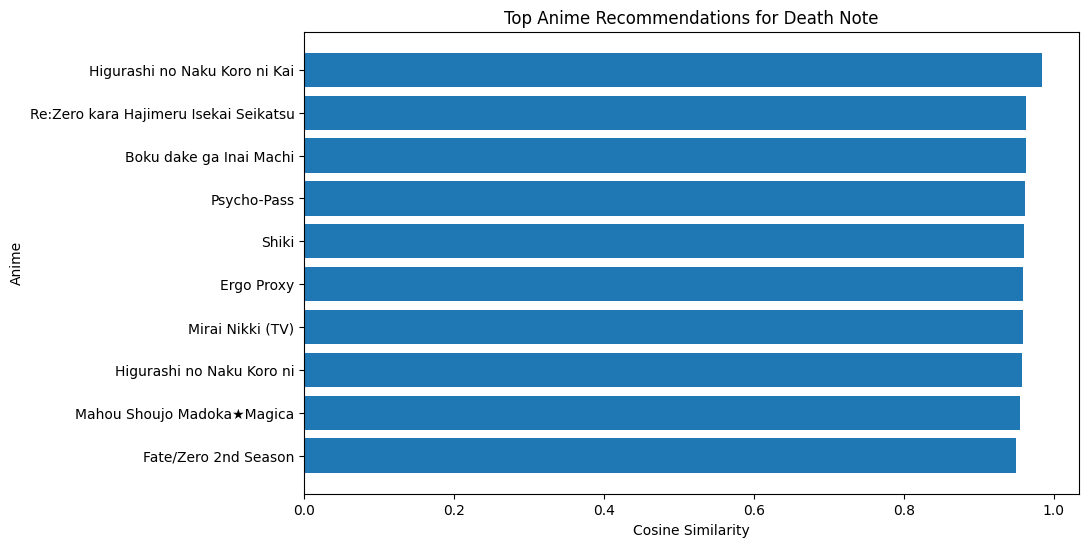

In [22]:
recommendations = recommend_anime(
    "Death Note",
    n=10,
    threshold=0.25
)
plt.figure(figsize=(10, 6))
plt.barh(
    recommendations["name"],
    recommendations["similarity"]
)
plt.xlabel("Cosine Similarity")
plt.ylabel("Anime")
plt.title("Top Anime Recommendations for Death Note")
plt.gca().invert_yaxis()
plt.show()

In [23]:
recommend_anime(
    "Naruto",
    n=10,
    threshold=0.25
)

,name,genre,type,rating,members,similarity
0,Dragon Ball Z,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,375662,0.984549
1,Katekyo Hitman Reborn!,"Action, Comedy, Shounen, Super Power",TV,8.37,258103,0.984343
2,Dragon Ball,"Adventure, Comedy, Fantasy, Martial Arts, Shou...",TV,8.16,316102,0.973034
3,Bleach,"Action, Comedy, Shounen, Super Power, Supernat...",TV,7.95,624055,0.969290
4,Ranma ½,"Comedy, Fantasy, Martial Arts, Slice of Life",TV,7.87,105212,0.965222
5,Prince of Tennis,"Action, Comedy, School, Shounen, Sports",TV,8.04,87643,0.965159
6,Fairy Tail,"Action, Adventure, Comedy, Fantasy, Magic, Sho...",TV,8.22,584590,0.964902
7,Yu☆Gi☆Oh!: Duel Monsters GX,"Action, Comedy, Fantasy, Game, Shounen",TV,7.23,74331,0.964885
8,InuYasha,"Action, Adventure, Comedy, Demons, Fantasy, Ma...",TV,7.89,281632,0.964496
9,Yu☆Gi☆Oh! Duel Monsters,"Adventure, Game, Shounen",TV,7.57,132099,0.962694


In [24]:
recommend_anime(
    "One Piece",
    n=10,
    threshold=0.25
)

,name,genre,type,rating,members,similarity
0,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",TV,8.54,896229,0.976430
1,Boku no Hero Academia,"Action, Comedy, School, Shounen, Super Power",TV,8.36,282002,0.967354
2,Hai to Gensou no Grimgar,"Action, Adventure, Drama, Fantasy",TV,7.87,213342,0.959695
3,Noragami Aragoto,"Action, Adventure, Shounen, Supernatural",TV,8.48,299434,0.954466
4,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,8.82,486824,0.954233
5,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,0.951474
6,One Punch Man,"Action, Comedy, Parody, Sci-Fi, Seinen, Super ...",TV,8.82,552458,0.951311
7,Magi: The Kingdom of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.50,245026,0.951220
8,Kill la Kill,"Action, Comedy, School, Super Power",TV,8.23,508118,0.950767
9,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",TV,8.39,717796,0.950539


In [25]:
recommend_anime(
    "Fullmetal Alchemist: Brotherhood",
    n=10,
    threshold=0.25
)

,name,genre,type,rating,members,similarity
0,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,8.33,600384,0.981113
1,Magi: The Kingdom of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.50,245026,0.962234
2,Magi: The Labyrinth of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.24,317513,0.953760
3,Hunter x Hunter,"Action, Adventure, Shounen, Super Power",TV,8.48,166255,0.952973
4,Juuni Kokuki,"Action, Adventure, Fantasy, Magic, Supernatural",TV,8.16,66646,0.950372
5,JoJo no Kimyou na Bouken: Diamond wa Kudakenai,"Action, Adventure, Comedy, Drama, Shounen, Sup...",TV,8.57,74074,0.949845
6,Great Teacher Onizuka,"Comedy, Drama, School, Shounen, Slice of Life",TV,8.77,268487,0.949541
7,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",TV,8.98,572888,0.947147
8,Hajime no Ippo,"Comedy, Drama, Shounen, Sports",TV,8.83,157670,0.945695
9,JoJo no Kimyou na Bouken: Stardust Crusaders 2...,"Action, Adventure, Drama, Shounen, Supernatural",TV,8.60,93657,0.942928


In [26]:
recommend_anime(
    "Shingeki no Kyojin",
    n=10,
    threshold=0.25
)

,name,genre,type,rating,members,similarity
0,One Piece,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",TV,8.58,504862,0.976430
1,Guilty Crown,"Action, Drama, Sci-Fi, Super Power",TV,7.81,460959,0.965755
2,Boku no Hero Academia,"Action, Comedy, School, Shounen, Super Power",TV,8.36,282002,0.961935
3,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",TV,8.98,572888,0.961327
4,Kill la Kill,"Action, Comedy, School, Super Power",TV,8.23,508118,0.957116
5,Claymore,"Action, Adventure, Demons, Fantasy, Shounen, S...",TV,7.92,316853,0.956184
6,Darker than Black: Kuro no Keiyakusha,"Action, Mystery, Sci-Fi, Super Power",TV,8.25,440334,0.954325
7,Zetsuen no Tempest,"Action, Drama, Fantasy, Magic, Mystery, Psycho...",TV,8.17,259900,0.952467
8,Toaru Kagaku no Railgun,"Action, Sci-Fi, Super Power",TV,7.87,231079,0.952448
9,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",TV,8.83,715151,0.952262


Performance Analysis: The recommendation system successfully identifies anime with similar genres, types, ratings, episode counts, and popularity using cosine similarity. As the similarity threshold increases, the number of recommendations decreases "For example, the number of possible recommendations decreases from 5,097 at a threshold of 0.20 to 173 at 0.90.", allowing the recommendation list to become more selective. However, the system is content-based and does not consider individual user preferences or watch history. It could be improved by adding user-item rating data, giving different weights to important features, and using more advanced recommendation techniques.

## Interview Questions:
### 1. Difference between User-Based and Item-Based Collaborative Filtering
User-based collaborative filtering recommends items by finding users with similar interests and suggesting what those similar users liked. Item-based collaborative filtering focuses on finding similar items and recommends them based on what a user has already liked. In simple terms, user-based looks for similar people, while item-based looks for similar items.

### 2. What is Collaborative Filtering, and how does it work?
Collaborative filtering is a recommendation technique that uses users' past behavior, such as ratings, likes, or purchases, to suggest items they might like. It works by finding similarities between users or items and then using those similarities to make recommendations. For example, if two users have similar anime preferences and one of them likes a new anime, that anime can be recommended to the other user.